In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\Marcus\Desktop\python pandas\superstore_data\version_control\superstore_clean.csv')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,31518,CA-2012-169397,2012-12-24,2013-01-09,First Class,JB-15925,Joni Blumstein,Consumer,Dublin,Ohio,...,OFF-BI-10002852,Office Supplies,Binders,Ibico Standard Transparent Covers,19.7760,4,0.70,-13.84,0.79,Medium
1,6224,US-2011-144729,2011-07-21,2011-08-07,First Class,SS-20140,Saphhira Shifley,Corporate,San Miguelito,Panama,...,OFF-FA-10002247,Office Supplies,Fasteners,"Oic Paper Clips, Bulk Pack",11.5440,2,0.40,-5.22,0.97,Medium
2,15333,IT-2014-4749412,2014-09-18,2014-09-28,Standard Class,MB-18085,Mick Brown,Unknown,Birmingham,England,...,OFF-AR-10003113,Office Supplies,Art,"Binney & Smith Pens, Blue",29.8500,5,0.50,-4.80,3.71,Medium
3,49259,NI-2013-4420,2013-04-10,2013-10-26,Standard Class,MP-7965,Michael Paige,Corporate,Lagos,Lagos,...,OFF-AVE-10004512,Office Supplies,Binders,"Avery Hole Reinforcements, Economy",1.3230,1,0.70,-3.09,0.06,Medium
4,24199,IN-2014-14423,2014-10-29,2014-11-27,First Class,DL-12925,Daniel Lacy,Consumer,Kendari,Sulawesi Tenggara,...,FUR-FU-10002362,Furnitures,Furnishings,"Advantus Door Stop, Black",131.4876,4,0.27,25.17,0.00,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51365,17526,ES-2014-2057259,2014-08-02,2014-05-19,First Class,PB-19150,Philip Brown,Consumer,Cagnes-Sur-Mer,Provence-Alpes-Cote D'Azur,...,OFF-PA-10002616,Office Supplies,Paper,"Green Bar Parchment Paper, Multicolor",108.5400,6,0.00,34.56,11.76,Medium
51366,36055,CA-2011-121573,2011-11-03,2011-08-07,Standard Class,SG-20605,Speros Goranitis,Consumer,New York City,New York,...,TEC-PH-10000984,Technology,Phones,Panasonic Kx-Tg9471B,783.9600,4,0.00,219.51,64.42,High
51367,43576,TU-2011-9190,2011-12-23,2012-01-11,Second Class,CM-1830,Cari Macintyre,Corporate,Corum,Corum,...,OFF-KIT-10002357,Office Supplies,Appliances,"Kitchenaid Blender, White",39.8400,1,0.60,-12.96,5.84,Medium
51368,22403,IN-2013-35388,2013-08-07,2013-11-19,Standard Class,IM-15055,Unknown,Consumer,Jakarta,Jakarta,...,OFF-AR-10000058,Office Supplies,Art,"Stanley Canvas, Water Color",38.4345,1,0.27,3.66,2.96,Medium


In [3]:
# How does the average quantity ordered per transaction vary across different Product Categories?

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51370 entries, 0 to 51369
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51370 non-null  int64  
 1   Order ID        51370 non-null  str    
 2   Order Date      51370 non-null  str    
 3   Ship Date       51370 non-null  str    
 4   Ship Mode       51370 non-null  str    
 5   Customer ID     51370 non-null  str    
 6   Customer Name   51336 non-null  str    
 7   Segment         51370 non-null  str    
 8   City            51351 non-null  str    
 9   State           51339 non-null  str    
 10  Country         51370 non-null  str    
 11  Postal Code     51370 non-null  int64  
 12  Market          51370 non-null  str    
 13  Region          51370 non-null  str    
 14  Product ID      51370 non-null  str    
 15  Category        51370 non-null  str    
 16  Sub-Category    51370 non-null  str    
 17  Product Name    51370 non-null  str    
 1

In [7]:
# How does the average quantity ordered per transaction vary across different Product Categories?

In [8]:
#category, quantity, mean
avg_quantity_categ = df.groupby(df['Category'])[['Quantity']].mean().round(2)
avg_quantity_categ

,Quantity
Category,
Furnitures,3.53
Office Supplies,3.45
Technology,3.46


In [9]:
avg_quantity_categ.reset_index(inplace=True)
avg_quantity_categ

,Category,Quantity
0,Furnitures,3.53
1,Office Supplies,3.45
2,Technology,3.46


In [12]:
avg_quantity_categ.rename(columns={"Quantity":"average_quantity"}, inplace=True)

In [13]:
avg_quantity_categ

,Category,average_quantity
0,Furnitures,3.53
1,Office Supplies,3.45
2,Technology,3.46


In [15]:
total_txn_categ = df.groupby(df['Category'])[['Quantity']].count()
total_txn_categ

,Quantity
Category,
Furnitures,9892
Office Supplies,31316
Technology,10162


In [16]:
avg_quantity_categ.set_index('Category',inplace=True)

In [17]:
avg_quantity_categ

,average_quantity
Category,
Furnitures,3.53
Office Supplies,3.45
Technology,3.46


In [18]:
avg_quantity_categ['total_txn'] = total_txn_categ
avg_quantity_categ

,average_quantity,total_txn
Category,,
Furnitures,3.53,9892
Office Supplies,3.45,31316
Technology,3.46,10162


In [19]:
avg_quantity_categ.reset_index(inplace=True)
avg_quantity_categ

,Category,average_quantity,total_txn
0,Furnitures,3.53,9892
1,Office Supplies,3.45,31316
2,Technology,3.46,10162


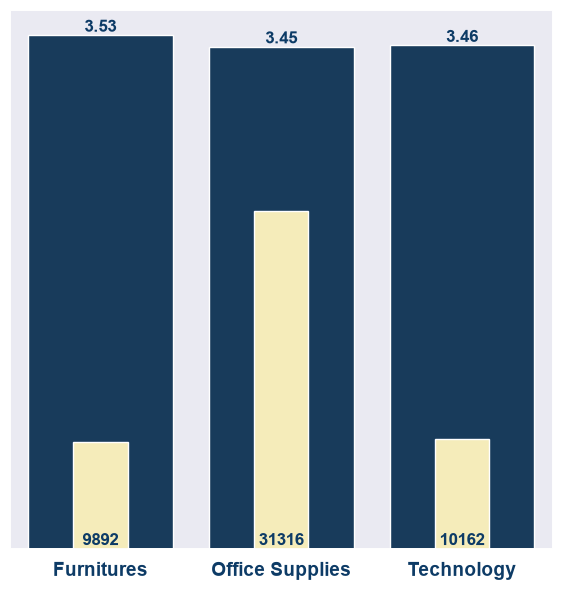

In [91]:
sns.set_theme()

fig, ax1 = plt.subplots(figsize=(7,7), sharey=True)

sns.barplot(
    data=avg_quantity_categ,
    x='Category',
    y='average_quantity',
    ax=ax1,
    color='#0d3b66'
)

ax2 = ax1.twinx()

sns.barplot(
    data=avg_quantity_categ,
    x='Category',
    y='total_txn',
    ax=ax2,
    color='#fff3b0',
    width=0.3
)

ax1.grid(False)
ax2.grid(False)

# ==================== y axis ====================
ax1.set_ylabel('')
ax1.set_yticklabels([])
ax1.tick_params(left=False)

ax2.set_ylabel('')
ax2.set_yticklabels([])
ax2.tick_params(right=False, bottom=False)
ax2.set_ylim(0, 50000)

# ==================== x axis ====================
ax1.set_xlabel('')
ax1.tick_params(axis='x', labelsize=14, labelcolor='#0d3b66')
plt.setp(ax1.get_xticklabels(), fontweight="bold")


# ==================== bar labels ====================
# average quantity → on top of navy bars
for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(
        f'{height:.2f}',
        (p.get_x() + p.get_width() / 2, height),
        ha='center', va='bottom',
        fontsize=12, fontweight='bold', color='#0d3b66'
    )

# total transactions → at the bottom of yellow bars
for p in ax2.patches:
    height = p.get_height()
    ax2.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width() / 2, 0),
        ha='center', va='bottom',
        fontsize=12, fontweight='bold', color='#0d3b66'
    )


In [92]:
# Business Question 7:
# How does the average quantity ordered per transaction vary across different Product Categories?

# Answer:
# All categories compete in the same ranges with only fraction in values. Furnitures takes the top for getting the most average quantity sold by 3.53,
# Technology gets 3.46, and take down by one step, Office Supplies has the same average quantity of 3.45.
# However, when it comes to total transaction made by every Categories, Office Supplies holds the top with the number of around 31k whilst Furnitures
# and Technology is ranging from around 9k to 10 but not more than 10k.